In [113]:
import pandas as pd
import numpy as np

In [114]:
climate_df = pd.read_csv('datasets/raw_climate_data.csv')

In [115]:
climate_df["Temp_max"] = climate_df["T2M_MAX"]
climate_df["Temp_min"] = climate_df["T2M_MIN"]
climate_df["Rainfall"] = climate_df["PRECTOTCORR"]
climate_df["Humidity"] = climate_df["RH2M"]
climate_df["Soil_pH"] = climate_df["Soil_pH_0_5cm"]

In [116]:
climate_df

,Date,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,County,Latitude,Longitude,Soil_pH_0_5cm,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH
0,2010-01-01,34.38,23.11,0.45,71.63,mombasa,-4.0435,39.6682,6.266667,34.38,23.11,0.45,71.63,6.266667
1,2010-01-02,34.48,23.29,2.17,72.44,mombasa,-4.0435,39.6682,6.266667,34.48,23.29,2.17,72.44,6.266667
2,2010-01-03,32.05,23.79,1.89,75.17,mombasa,-4.0435,39.6682,6.266667,32.05,23.79,1.89,75.17,6.266667
3,2010-01-04,34.33,23.96,0.39,70.45,mombasa,-4.0435,39.6682,6.266667,34.33,23.96,0.39,70.45,6.266667
4,2010-01-05,35.09,23.48,1.44,70.43,mombasa,-4.0435,39.6682,6.266667,35.09,23.48,1.44,70.43,6.266667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257508,2024-12-27,27.77,14.79,0.14,69.84,nairobi,-1.2864,36.8172,6.225000,27.77,14.79,0.14,69.84,6.225000
257509,2024-12-28,27.24,14.91,0.07,68.94,nairobi,-1.2864,36.8172,6.225000,27.24,14.91,0.07,68.94,6.225000
257510,2024-12-29,28.55,13.60,0.01,64.06,nairobi,-1.2864,36.8172,6.225000,28.55,13.60,0.01,64.06,6.225000
257511,2024-12-30,28.04,13.93,0.05,65.32,nairobi,-1.2864,36.8172,6.225000,28.04,13.93,0.05,65.32,6.225000


In [117]:
climate_df = climate_df[["County", "Date", "Temp_max", "Temp_min", "Rainfall", "Humidity", "Soil_pH"]]

In [118]:
climate_df

,County,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH
0,mombasa,2010-01-01,34.38,23.11,0.45,71.63,6.266667
1,mombasa,2010-01-02,34.48,23.29,2.17,72.44,6.266667
2,mombasa,2010-01-03,32.05,23.79,1.89,75.17,6.266667
3,mombasa,2010-01-04,34.33,23.96,0.39,70.45,6.266667
4,mombasa,2010-01-05,35.09,23.48,1.44,70.43,6.266667
...,...,...,...,...,...,...,...
257508,nairobi,2024-12-27,27.77,14.79,0.14,69.84,6.225000
257509,nairobi,2024-12-28,27.24,14.91,0.07,68.94,6.225000
257510,nairobi,2024-12-29,28.55,13.60,0.01,64.06,6.225000
257511,nairobi,2024-12-30,28.04,13.93,0.05,65.32,6.225000


In [87]:
climate_df.isna().sum()

County      0
Date        0
Temp_max    0
Temp_min    0
Rainfall    0
Humidity    0
Soil_pH     0
dtype: int64

In [119]:
# crop prices
crop_prices_df = pd.read_csv('datasets/raw_crop_data.csv')

In [120]:
crop_prices_df

,Commodity,Wholesale,Retail,County,Date
0,Red Irish potato,50.00000,60.00,Trans-Nzoia,2026-03-03
1,Red Irish potato,41.33000,45.33,Trans-Nzoia,2026-03-02
2,Red Irish potato,50.00000,60.00,Trans-Nzoia,2026-02-27
3,Red Irish potato,40.00000,45.33,Trans-Nzoia,2026-02-26
4,Red Irish potato,50.00000,65.00,Trans-Nzoia,2026-02-25
...,...,...,...,...,...
167637,Macadamia Seed,174.20537,300.00,Kisumu,2021-05-24
167638,Macadamia Seed,50.00000,60.00,Taita-Taveta,2021-05-24
167639,Macadamia Seed,174.20537,350.00,Kisumu,2021-05-24
167640,Macadamia Seed,50.00000,60.00,Taita-Taveta,2021-05-24


In [121]:
crop_prices_df["County"] = crop_prices_df["County"].str.strip().str.lower()

In [122]:
# check if there is any null on Wholesale
crop_prices_df["Wholesale"].isna().sum()

np.int64(3191)

In [123]:
# convert null cellls into mean
crop_prices_df["Wholesale"] = crop_prices_df["Wholesale"].fillna(crop_prices_df["Wholesale"].mean())

In [124]:
# check if null 
crop_prices_df["Wholesale"].isna().sum()

np.int64(0)

In [125]:
# check if there is any null cell for Retail, if true use the mean
crop_prices_df["Retail"].isna().sum()
crop_prices_df["Retail"] = crop_prices_df["Retail"].fillna(crop_prices_df["Retail"].mean())
crop_prices_df["Retail"].isna().sum()

np.int64(0)

In [126]:
# Rename column Commodity to Crop
crop_prices_df["Crop"] = crop_prices_df["Commodity"]

In [127]:
# select the necessary columns
crop_prices_df = crop_prices_df[["County", "Crop", "Wholesale", "Retail","Date"]] 

In [128]:
crop_prices_df

,County,Crop,Wholesale,Retail,Date
0,trans-nzoia,Red Irish potato,50.00000,60.00,2026-03-03
1,trans-nzoia,Red Irish potato,41.33000,45.33,2026-03-02
2,trans-nzoia,Red Irish potato,50.00000,60.00,2026-02-27
3,trans-nzoia,Red Irish potato,40.00000,45.33,2026-02-26
4,trans-nzoia,Red Irish potato,50.00000,65.00,2026-02-25
...,...,...,...,...,...
167637,kisumu,Macadamia Seed,174.20537,300.00,2021-05-24
167638,taita-taveta,Macadamia Seed,50.00000,60.00,2021-05-24
167639,kisumu,Macadamia Seed,174.20537,350.00,2021-05-24
167640,taita-taveta,Macadamia Seed,50.00000,60.00,2021-05-24


In [129]:
# merge the dataset
merged_df = pd.merge(
    crop_prices_df,
    climate_df,
    on=["County", "Date"],
    how="inner"
)

In [130]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH
0,nairobi,Red Irish potato,60.380503,140.0,2024-11-11,24.60,16.82,3.84,77.97,6.225000
1,kakamega,Red Irish potato,70.000000,100.0,2024-10-10,23.37,14.18,4.49,76.42,5.450000
2,bomet,Red Irish potato,84.000000,120.0,2024-10-09,25.16,11.24,0.11,68.98,6.766667
3,nakuru,Red Irish potato,60.380503,30.0,2024-10-09,20.83,9.56,2.35,80.12,6.766667
4,bungoma,Red Irish potato,70.000000,80.0,2024-10-09,24.80,17.07,8.66,80.69,5.450000
...,...,...,...,...,...,...,...,...,...,...
101938,kisumu,Macadamia Seed,174.205370,350.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000
101939,kisumu,Macadamia Seed,174.205370,300.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000
101940,kisumu,Macadamia Seed,174.205370,300.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000
101941,kisumu,Macadamia Seed,174.205370,350.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000


In [131]:
# check if any column have null values
merged_df.isna().sum()

County       0
Crop         0
Wholesale    0
Retail       0
Date         0
Temp_max     0
Temp_min     0
Rainfall     0
Humidity     0
Soil_pH      0
dtype: int64

In [132]:
# date decomposition
import pandas as pd

# Ensure your Date column is in the correct datetime format
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

# Extract Year, Month, and Day
merged_df['Year'] = merged_df['Date'].dt.year
merged_df['Month'] = merged_df['Date'].dt.month
merged_df['Day'] = merged_df['Date'].dt.day

# Optional: Extract the Quarter (useful for seasonal financial trends)
merged_df['Quarter'] = merged_df['Date'].dt.quarter

In [133]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter
0,nairobi,Red Irish potato,60.380503,140.0,2024-11-11,24.60,16.82,3.84,77.97,6.225000,2024,11,11,4
1,kakamega,Red Irish potato,70.000000,100.0,2024-10-10,23.37,14.18,4.49,76.42,5.450000,2024,10,10,4
2,bomet,Red Irish potato,84.000000,120.0,2024-10-09,25.16,11.24,0.11,68.98,6.766667,2024,10,9,4
3,nakuru,Red Irish potato,60.380503,30.0,2024-10-09,20.83,9.56,2.35,80.12,6.766667,2024,10,9,4
4,bungoma,Red Irish potato,70.000000,80.0,2024-10-09,24.80,17.07,8.66,80.69,5.450000,2024,10,9,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101938,kisumu,Macadamia Seed,174.205370,350.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2
101939,kisumu,Macadamia Seed,174.205370,300.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2
101940,kisumu,Macadamia Seed,174.205370,300.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2
101941,kisumu,Macadamia Seed,174.205370,350.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2


In [104]:
# hot encode crop and county
from sklearn.preprocessing import LabelEncoder

# Initialize encoders
county_encoder = LabelEncoder()
crop_encoder = LabelEncoder()

# Fit and transform the columns
merged_df['County_Encoded'] = county_encoder.fit_transform(merged_df['County'])
merged_df['Crop_Encoded'] = crop_encoder.fit_transform(merged_df['Crop'])

# Create mapping dictionaries for later use (Decoding)
county_mapping = dict(zip(county_encoder.classes_, county_encoder.transform(county_encoder.classes_)))
crop_mapping = dict(zip(crop_encoder.classes_, crop_encoder.transform(crop_encoder.classes_)))

print("Crop Mapping:", crop_mapping)

Crop Mapping: {'Apples': np.int64(0), 'Arrow Root': np.int64(1), 'Avocado': np.int64(2), 'Banana (Cooking)': np.int64(3), 'Banana (Plantain)': np.int64(4), 'Banana (Ripening)': np.int64(5), 'Beans (Canadian wonder)': np.int64(6), 'Beans (Mwezi Moja)': np.int64(7), 'Beans (Mwitemania)': np.int64(8), 'Beans (Yellow-Green)': np.int64(9), 'Beans Red Haricot (Wairimu)': np.int64(10), 'Beans Rosecoco': np.int64(11), 'Beans Rosecoco (Nyayo)': np.int64(12), 'Cabbages': np.int64(13), 'Carrots': np.int64(14), 'Cassava Chips (dry)': np.int64(15), 'Cassava Fresh': np.int64(16), 'Coconut': np.int64(17), 'Coffee': np.int64(18), 'Cotton': np.int64(19), 'Cowpeas': np.int64(20), 'Cucumber': np.int64(21), 'Dolichos lablab (Njahi)': np.int64(22), 'Dry Maize': np.int64(23), 'Dry Onions': np.int64(24), 'Dry Peas': np.int64(25), 'Egg plant (Brinjals)': np.int64(26), 'Finger Millet': np.int64(27), 'French beans': np.int64(28), 'Fresh Peas': np.int64(29), 'Garlic': np.int64(30), 'Ginger': np.int64(31), 'Grape

In [105]:
merged_df

,County,Crop,Wholesale,Retail,Date,Temp_max,Temp_min,Rainfall,Humidity,Soil_pH,Year,Month,Day,Quarter,County_Encoded,Crop_Encoded
0,nairobi,Red Irish potato,60.380503,140.0,2024-11-11,24.60,16.82,3.84,77.97,6.225000,2024,11,11,4,26,49
1,kakamega,Red Irish potato,70.000000,100.0,2024-10-10,23.37,14.18,4.49,76.42,5.450000,2024,10,10,4,9,49
2,bomet,Red Irish potato,84.000000,120.0,2024-10-09,25.16,11.24,0.11,68.98,6.766667,2024,10,9,4,1,49
3,nakuru,Red Irish potato,60.380503,30.0,2024-10-09,20.83,9.56,2.35,80.12,6.766667,2024,10,9,4,27,49
4,bungoma,Red Irish potato,70.000000,80.0,2024-10-09,24.80,17.07,8.66,80.69,5.450000,2024,10,9,4,2,49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101938,kisumu,Macadamia Seed,174.205370,350.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2,15,39
101939,kisumu,Macadamia Seed,174.205370,300.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2,15,39
101940,kisumu,Macadamia Seed,174.205370,300.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2,15,39
101941,kisumu,Macadamia Seed,174.205370,350.0,2021-05-24,23.16,17.57,5.52,83.93,5.450000,2021,5,24,2,15,39


In [106]:
# Check if any crop has fewer than 2 occurrences
counts = merged_df['Crop_Encoded'].value_counts()
print(counts[counts < 2])

Crop_Encoded
19    1
Name: count, dtype: int64


In [107]:
# The direct way using the encoder
problem_crop = crop_encoder.inverse_transform([19])[0]
print(f"Crop 19 is: {problem_crop}")

Crop 19 is: Cotton


In [108]:
import pandas as pd
import numpy as np
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

merged_df['Temp_Range'] = merged_df['Temp_max'] - merged_df['Temp_min']
merged_df['Rain_per_Temp'] = merged_df['Rainfall'] / (merged_df['Temp_max'] + 1)

# 1. Load your Biological Requirements
# Columns: Crop, Min_Temp, Max_Temp, Min_Rain, Max_Rain, Min_pH, Max_pH
req_df = pd.read_csv('datasets/crop_requirements/crop_requirements.csv')
crop_limits = req_df.set_index('Crop').to_dict('index')

# 2. Define Features
suit_features = ['Temp_max', 'Temp_min', 'Temp_Range', 'Rainfall', 'Humidity', 'Soil_pH', 'County_Encoded', 'Month', 'Rain_per_Temp']
price_features = ['Crop_Encoded', 'County_Encoded', 'Month', 'Year', 'Rainfall']

# 3. Scale Suitability Data
scaler = StandardScaler()
X_suit = scaler.fit_transform(merged_df[suit_features])
y_suit = merged_df['Crop_Encoded']

# 4. Reshape Price Data for LSTM (Samples, Time_Steps, Features)
X_price = merged_df[price_features].values
X_price_lstm = X_price.reshape((X_price.shape[0], 1, X_price.shape[1]))
y_price = merged_df['Wholesale'].values

In [109]:
# 1. First, do the filtering (as we did before)
crop_counts = y_suit.value_counts()
valid_crops = crop_counts[crop_counts >= 2].index
mask = y_suit.isin(valid_crops)

# Keep the original NAMES for re-encoding
X_suit_filtered = X_suit[mask]
y_suit_names_filtered = merged_df.loc[mask, 'Crop'] 

# 2. RE-ENCODE starting from zero (This removes the "gap" at 19)
new_crop_encoder = LabelEncoder()
y_suit_final = new_crop_encoder.fit_transform(y_suit_names_filtered)

# 3. Update your mapping dictionary (CRITICAL for your recommendations)
crop_mapping = dict(zip(new_crop_encoder.classes_, range(len(new_crop_encoder.classes_))))
id_to_crop = {v: k for k, v in crop_mapping.items()}

In [110]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Split your data (if you haven't already)
# X_train, X_test, y_train, y_test = train_test_split(X_suit, y_suit, test_size=0.2, stratify=y_suit, random_state=42)

# # 2. Re-fit on training data and predict on test data
xgb_model = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, objective='multi:softprob')
# xgb_model.fit(X_train, y_train)
# y_pred = xgb_model.predict(X_test)


# 4. Now split the filtered data
X_train, X_test, y_train, y_test = train_test_split(
    X_suit_filtered, 
    y_suit_final, 
    test_size=0.2, 
    stratify=y_suit_final, 
    random_state=42
)

# 5. Fit the model
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
print("Model trained successfully!")

# 3. Print Accuracy Metrics
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model trained successfully!
Overall Accuracy: 5.03%

Classification Report:
              precision    recall  f1-score   support

           0       0.04      0.07      0.05       444
           1       0.00      0.00      0.00       313
           2       0.02      0.03      0.03       306
           3       0.00      0.00      0.00       282
           4       0.06      0.03      0.04       460
           5       0.02      0.01      0.01       356
           6       0.06      0.07      0.06       495
           7       0.05      0.09      0.06       460
           8       0.01      0.00      0.00       361
           9       0.01      0.00      0.01       301
          10       0.02      0.01      0.01       364
          11       0.02      0.01      0.01       409
          12       0.03      0.03      0.03       364
          13       0.03      0.04      0.03       222
          14       0.01      0.00      0.00       256
          15       0.06      0.10      0.07       463
     

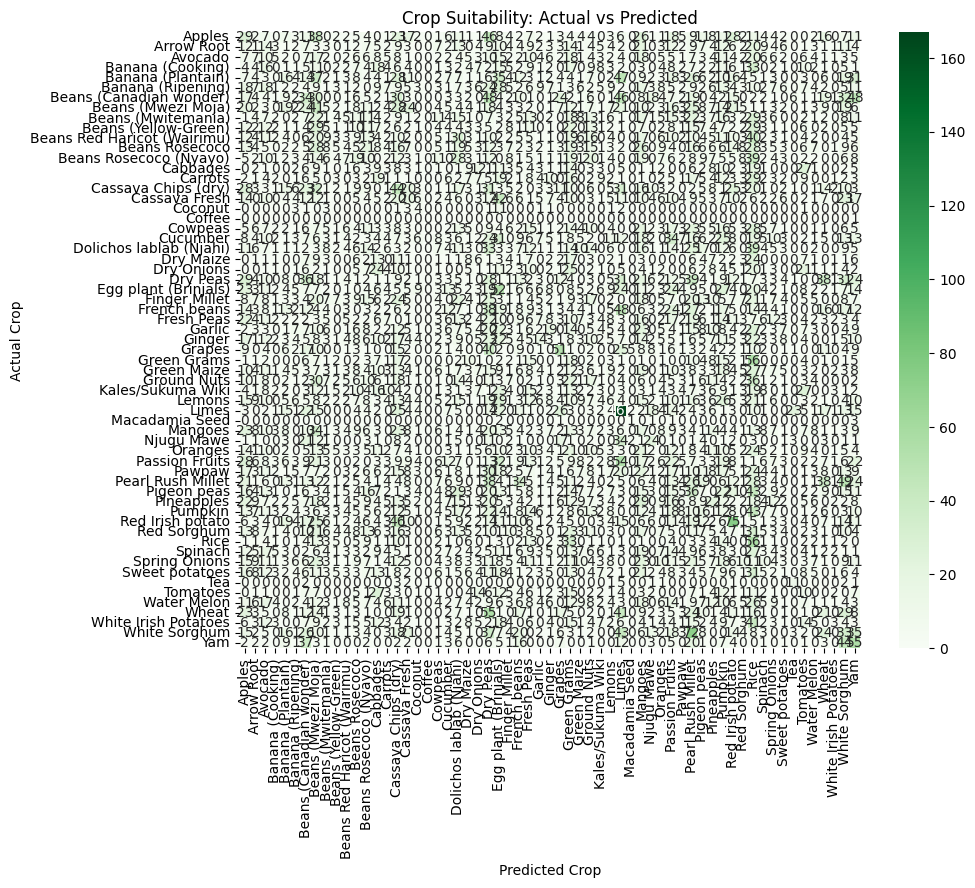

In [79]:
# 4. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=crop_mapping.keys(), 
            yticklabels=crop_mapping.keys())
plt.title('Crop Suitability: Actual vs Predicted')
plt.ylabel('Actual Crop')
plt.xlabel('Predicted Crop')
plt.show()